## General Strategy

1. **Compress light curves into 3 SALT2 numbers**  
   Each SN is reduced to $(x_0, x_1, c)$.  
   These are the parameters in my CSV file.

2. **Define a distance estimator (Tripp relation)**  
   $
   \mu_{\text{obs}} = -2.5\log_{10}x_0 + \alpha x_1 - \beta c + M_B
   $
   where $\alpha, \beta, M_B$ are unknown *global nuisance parameters*.

3. **Get the theoretical expectation from cosmology**  
   For each redshift $z$, compute  
   $
   \mu_{\text{th}}(z; \Omega_M,H_0) =
   5\log_{10}\!\left(\frac{d_L(z)}{10\ \mathrm{pc}}\right),
   $  
   where $d_L(z)$ is the luminosity distance in your chosen cosmology  
   (e.g. flat $\Lambda$CDM).  
   In practice, $M_B$ absorbs $H_0$, so $H_0$ is fixed to a convenient value. So that's all you need. These things are analytically marginalizable. 

4. **Compare observed vs. theory**  
   Define the residuals:  
   $
   \Delta\mu_i = \mu_{\text{obs},i} - \mu_{\text{th}}(z_i).
   $

5. **Fit the nuisance parameters $\alpha,\beta,M_B$**  
   Choose them to minimize scatter in the Hubble diagram, i.e. minimize  
   $
   \chi^2 = \sum_i \frac{\Delta\mu_i^2}{\sigma_i^2},
   $  
   where $\sigma_i^2$ is the per-SN variance (measurement error + peculiar velocity + intrinsic scatter).  
   This is exactly what the iterative weighted least squares + MLE update for 
   $\sigma_{\rm int}$ is doing in the code.


   Reminder that M_b H_o are analytically marignailizable just like the project we did before. 

7. **Visualize**  
   - Plot $\mu_{\text{obs}}$ vs. $z$ (the Hubble diagram), overlay $\mu_{\text{th}}(z)$.  
   - Plot residuals vs. $z$, $x_1$, and $c$.  
   - Plot a histogram of residuals to show the scatter.

Fitted (global scalars):
  alpha = 0.140 ± 0.004
  beta  = 2.838 ± 0.029
  M_B   = 29.756 ± 0.004
  sigma_int = 0.195  |  chi2/dof = 1.03


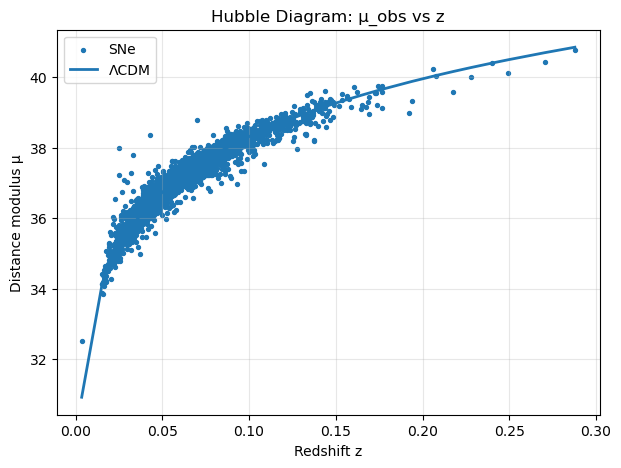

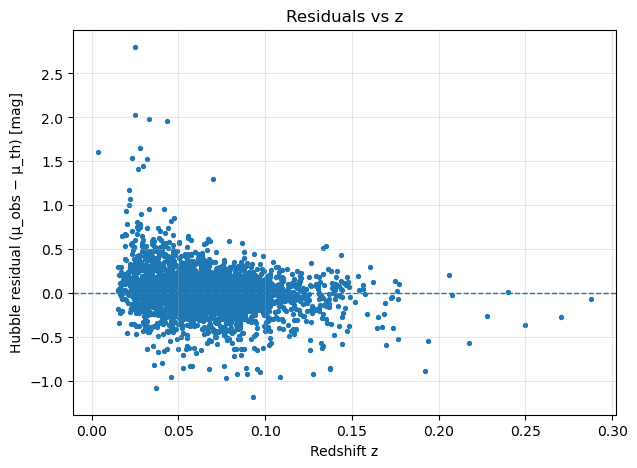

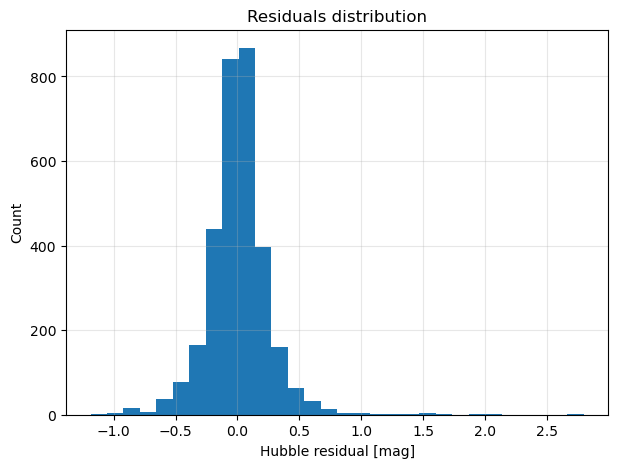

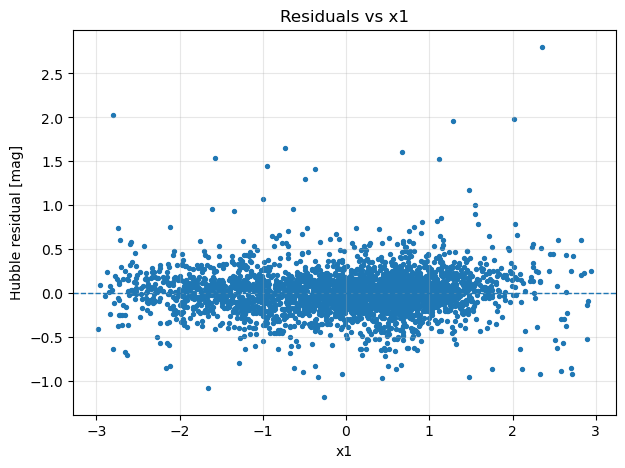

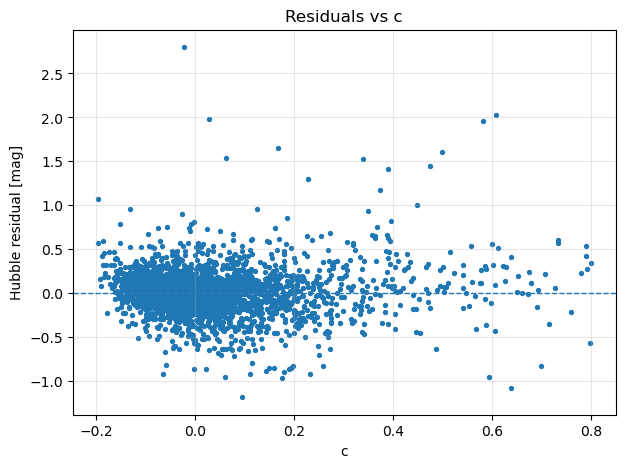

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from astropy.cosmology import FlatLambdaCDM

# =========================
# CONFIG
# =========================
CSV = "/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_snia_data.csv"
H0, OM0 = 70.0, 0.3          # cosmology for mu_th (MB absorbs H0 offset)
SIGMA_V = 300.0              # km/s peculiar velocity scatter
CUTS = dict(x1=(-3, 3), c=(-0.2, 0.8), fitprob_min=1e-7)

LOG10E = 1/np.log(10)

def mu0_from_x0(x0):
    """-2.5 log10 x0"""
    return -2.5*np.log10(x0)

def fit_alpha_beta_MB(df):
    # -------- Basic quality cuts --------
    mask = (
        np.isfinite(df["x0"]) & (df["x0"] > 0) &
        np.isfinite(df["x1"]) & np.isfinite(df["c"]) &
        np.isfinite(df["x0_err"]) & np.isfinite(df["x1_err"]) & np.isfinite(df["c_err"]) &
        np.isfinite(df["redshift"]) & (df["redshift"] > 0)
    )
    if "fitprob" in df.columns:
        mask &= (df["fitprob"] >= CUTS["fitprob_min"])
    mask &= df["x1"].between(*CUTS["x1"]) & df["c"].between(*CUTS["c"])
    d = df.loc[mask].copy()
    if len(d) < 10:
        raise ValueError(f"Too few SNe after cuts: {len(d)}")

    # -------- Columns --------
    x0, x1, c = d["x0"].values, d["x1"].values, d["c"].values
    x0e, x1e, ce = d["x0_err"].values, d["x1_err"].values, d["c_err"].values
    z = d["redshift"].values
    ze = d.get("redshift_err", pd.Series(np.zeros(len(d)), index=d.index)).values

    # Covariances (fill with zeros if missing)
    cov_x0_x1 = d.get("cov_x0_x1", pd.Series(np.zeros(len(d)), index=d.index)).values
    cov_x0_c  = d.get("cov_x0_c",  pd.Series(np.zeros(len(d)), index=d.index)).values
    cov_x1_c  = d.get("cov_x1_c",  pd.Series(np.zeros(len(d)), index=d.index)).values

    # -------- Cosmology & targets --------
    cosmo = FlatLambdaCDM(H0=H0, Om0=OM0)
    mu_th = cosmo.distmod(z).value
    mu0 = mu0_from_x0(x0)
    t = mu_th - mu0                      # target for linear part
    X = np.column_stack([x1, -c, np.ones_like(x1)])  # columns: [x1, -c, 1], shape (N,3)

    # -------- Variance helpers --------
    def sigma_meas_sq(alpha, beta):
        dmu_dx0 = -2.5*LOG10E*(1.0/x0)
        dmu_dx1 = alpha
        dmu_dc  = -beta
        var = (
            (dmu_dx0**2)*x0e**2 +
            (dmu_dx1**2)*x1e**2 +
            (dmu_dc**2)*ce**2 +
            2*dmu_dx0*dmu_dx1*cov_x0_x1 +
            2*dmu_dx0*dmu_dc *cov_x0_c  +
            2*dmu_dx1*dmu_dc *cov_x1_c
        )
        return np.clip(var, 0, None)

    def sigma_pv_sq():
        c_kms = 299_792.458
        term = (5/np.log(10))*(SIGMA_V/(c_kms*np.clip(z, 1e-4, None)))
        return term**2

    def sigma_z_sq():
        dz = np.maximum(ze, 1e-5)
        mu_p = FlatLambdaCDM(H0=H0, Om0=OM0).distmod(z+dz).value
        mu_m = FlatLambdaCDM(H0=H0, Om0=OM0).distmod(np.clip(z-dz, 1e-6, None)).value
        dmu_dz = (mu_p - mu_m)/(2*dz)
        return (dmu_dz*ze)**2

    # -------- Iterative WLS + sigma_int MLE --------
    alpha, beta, MB = 0.15, 3.0, -19.3   # initial guess
    sigma_int = 0.1
    for _ in range(6):
        v_meas = sigma_meas_sq(alpha, beta)
        v_tot = v_meas + sigma_pv_sq() + sigma_z_sq() + sigma_int**2
        w = 1.0/np.clip(v_tot, 1e-12, None)

        # Weighted least squares: ensure RHS is 1-D
        W = np.sqrt(w)[:, None]         # (N,1)
        Xw = W * X                      # (N,3)
        tw = (W[:, 0] * t)              # (N,)  <-- 1-D RHS
        theta, *_ = np.linalg.lstsq(Xw, tw, rcond=None)
        theta = np.asarray(theta).ravel()    # (3,)
        alpha, beta, MB = theta.tolist()     # scalars

        # MLE for sigma_int
        def nll(log_s):
            s = np.exp(log_s)
            v = v_meas + sigma_pv_sq() + sigma_z_sq() + s**2
            r = t - (alpha*x1 - beta*c + MB)
            return 0.5*np.sum(np.log(2*np.pi*np.clip(v,1e-12,None)) + (r*r)/np.clip(v,1e-12,None))
        res = minimize(nll, x0=np.log(max(sigma_int,1e-4)),
                       bounds=[(np.log(1e-4), np.log(0.5))])
        sigma_int = float(np.exp(res.x[0]))

    # -------- Parameter covariance from final WLS --------
    v_meas = sigma_meas_sq(alpha, beta)
    v_tot = v_meas + sigma_pv_sq() + sigma_z_sq() + sigma_int**2
    w = 1.0/np.clip(v_tot, 1e-12, None)
    XtWX = (X.T * w) @ X
    cov = np.linalg.inv(XtWX)
    se_alpha, se_beta, se_MB = np.sqrt(np.diag(cov))

    mu_obs = mu0 + alpha*x1 - beta*c + MB
    resid = mu_obs - mu_th
    chi2 = np.sum(w*resid*resid)
    ndof = len(resid) - 3

    out = dict(
        alpha=float(alpha), alpha_err=float(se_alpha),
        beta=float(beta),   beta_err=float(se_beta),
        MB=float(MB),       MB_err=float(se_MB),
        sigma_int=float(sigma_int),
        chi2_dof=float(chi2/max(ndof,1)),
        z=z, mu_obs=mu_obs, mu_th=mu_th,
        resid=resid, x1=x1, c=c
    )
    return out

# =========================
# RUN
# =========================
df = pd.read_csv(CSV)
res = fit_alpha_beta_MB(df)

print("Fitted (global scalars):")
print(f"  alpha = {res['alpha']:.3f} ± {res['alpha_err']:.3f}")
print(f"  beta  = {res['beta']:.3f} ± {res['beta_err']:.3f}")
print(f"  M_B   = {res['MB']:.3f} ± {res['MB_err']:.3f}")
print(f"  sigma_int = {res['sigma_int']:.3f}  |  chi2/dof = {res['chi2_dof']:.2f}")

# =========================
# PLOTS
# =========================
z, mu_obs, mu_th = res["z"], res["mu_obs"], res["mu_th"]
resid, x1, c = res["resid"], res["x1"], res["c"]

# 1) Hubble diagram
plt.figure(figsize=(7,5))
plt.scatter(z, mu_obs, s=8, label="SNe")
idx = np.argsort(z)
plt.plot(z[idx], mu_th[idx], label="ΛCDM", linewidth=2)
plt.xlabel("Redshift z")
plt.ylabel("Distance modulus μ")
plt.title("Hubble Diagram: μ_obs vs z")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# 2) Residuals vs z
plt.figure(figsize=(7,5))
plt.scatter(z, resid, s=8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Redshift z")
plt.ylabel("Hubble residual (μ_obs − μ_th) [mag]")
plt.title("Residuals vs z")
plt.grid(True, alpha=0.3)
plt.show()

# 3) Residuals histogram
plt.figure(figsize=(7,5))
plt.hist(resid, bins=30)
plt.xlabel("Hubble residual [mag]")
plt.ylabel("Count")
plt.title("Residuals distribution")
plt.grid(True, alpha=0.3)
plt.show()

# 4a) Residuals vs x1
plt.figure(figsize=(7,5))
plt.scatter(x1, resid, s=8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("x1")
plt.ylabel("Hubble residual [mag]")
plt.title("Residuals vs x1")
plt.grid(True, alpha=0.3)
plt.show()

# 4b) Residuals vs c
plt.figure(figsize=(7,5))
plt.scatter(c, resid, s=8)
plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("c")
plt.ylabel("Hubble residual [mag]")
plt.title("Residuals vs c")
plt.grid(True, alpha=0.3)
plt.show()


# General Strategy Again #

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from astropy.cosmology import FlatLambdaCDM

# General Strategy (with $M_B$ marginalized)

1. **Load SALT2 parameters from the CSV**  

   Each SN already has $(x_0, x_1, c)$ provided in the dataset.  
   These are the parameters we will use. Note: if these were not provided we would end up having to use the SALT 2 Model to fit these light curves.



In [7]:
df = pd.read_csv("/Users/pittsburghgraduatestudent/repos/first_paper_blast_webapi/data_ZTF/ZTF_snia_data.csv")

# === Clean data by dropping rows with missing essential columns ===
lc_cols = ["x0", "x1", "c", "x0_err", "x1_err", "c_err"]
df_clean = df.dropna(subset=lc_cols).copy()

print(f"Kept {len(df_clean)} SNe after removing missing LC params "
      f"(dropped {len(df) - len(df_clean)}).")

# === Extract SALT2 parameters and uncertainties (from the CLEANED frame) ===
x0 = df_clean["x0"].to_numpy()
x1 = df_clean["x1"].to_numpy()
c  = df_clean["c"].to_numpy()

# 1σ uncertainties
x0_err = df_clean["x0_err"].to_numpy()
x1_err = df_clean["x1_err"].to_numpy()
c_err  = df_clean["c_err"].to_numpy()

# Covariances (assume columns exist; will raise KeyError if not)
cov_x0_x1 = df_clean["cov_x0_x1"].to_numpy()
cov_x0_c  = df_clean["cov_x0_c"].to_numpy()
cov_x1_c  = df_clean["cov_x1_c"].to_numpy()

# (Optional) redshift info for later steps
z  = df_clean["redshift"].to_numpy()
ze = df_clean.get("redshift_err", pd.Series(0.0, index=df_clean.index)).to_numpy()

Kept 3576 SNe after removing missing LC params (dropped 52).


2. **Distance estimator (Tripp relation)**  

   The SALT2-based distance modulus estimate is

   $
   \mu_{\text{obs}} = -2.5\log_{10}x_0 + \alpha x_1 - \beta c + M_B.
   $

   Here $\alpha,\beta$ are global nuisance parameters describing stretch and color corrections.  
   $M_B$ is a global intercept degenerate with $H_0$.  

   NOTE: In the analysis, $M_B$ is **not fit explicitly**. It is analytically marginalized out (equivalent to subtracting a weighted mean offset).

   NOTE: these are defined in their function form b/c of the fitting function later. 

In [11]:
# === Step 2: Distance estimator (Tripp relation) ===
import numpy as np

def mu_obs_no_MB(x0: np.ndarray, x1: np.ndarray, c: np.ndarray,
                 alpha: float, beta: float) -> np.ndarray:
    """
    Intercept-free Tripp relation (M_B marginalized):
      μ*_obs = -2.5 log10 x0 + α x1 - β c
    Returns array aligned with input SNe.
    """
    return -2.5 * np.log10(x0) + alpha * x1 - beta * c

3. **Theoretical expectation from cosmology**  
For each redshift $z$, compute  
$
\mu_{\text{th}}(z;\Omega_M,H_0) = 5\log_{10}\!\left(\frac{d_L(z)}{10\,\mathrm{pc}}\right),
$  
where $d_L(z)$ is the luminosity distance for a chosen cosmology (e.g. flat $\Lambda$CDM).  
Since $M_B$ absorbs $H_0$, you can fix $H_0$ to any convenient value.

In [12]:
# Choose a convenient H0; M_B absorbs the absolute scale anyway.
H0  = 70.0   # km/s/Mpc
OM0 = 0.3    # Ω_M

_cosmo = FlatLambdaCDM(H0=H0, Om0=OM0)

def mu_th_from_z(z: np.ndarray) -> np.ndarray:
    """
    Theoretical distance modulus for redshifts z in flat ΛCDM:
      μ_th(z) = 5 log10(d_L(z) / 10 pc)
    Returns magnitudes as a NumPy array.
    """
    return _cosmo.distmod(z).value



4. **Residuals**  

Define the differences between observation and theory:  

$
\Delta\mu_i = \mu_{\text{obs},i} - \mu_{\text{th}}(z_i).
$

With $M_B$ marginalized, this effectively means comparing *centered* values of $\mu_{\text{obs}}$ and $\mu_{\text{th}}$.


We start with the likelihood for a given M_B:

$
\chi^2(M_B) ;=; \sum_i \frac{\big[(\mu^*{\text{obs},i} + M_B) - \mu{\text{th},i}\big]^2}{\sigma_i^2}.
$

Take derivative w.r.t. M_B, set to zero to find the minimum:

$
\frac{\partial \chi^2}{\partial M_B} = 0
\quad \Rightarrow \quad
M_B^\star ;=; \frac{\sum_i w_i , (\mu_{\text{th},i} - \mu^*_{\text{obs},i})}{\sum_i w_i},
$

where

$
w_i ;=; \frac{1}{\sigma_i^2}.
$




In [ ]:
def weighted_mean(u: np.ndarray, w: np.ndarray | None = None) -> float:
    """Weighted mean; if w is None, fall back to simple mean."""
    if w is None:
        return float(np.mean(u))
    return float(np.sum(w * u) / np.sum(w))

def hubble_residuals(mu_obs_star: np.ndarray, mu_th: np.ndarray,
                     w: np.ndarray | None = None):
    """
    Return residuals Δμ with MB removed:
      Δμ_i = (μ*_obs,i - μ_th,i) - <μ*_obs - μ_th>_w
    Also return the implied MB* (the offset we'd add to μ*_obs to align with μ_th):
      MB* = < μ_th - μ*_obs >_w
    """
    raw = mu_obs_star - mu_th
    off = weighted_mean(raw, w)              # this is <μ*_obs - μ_th>_w
    resid = raw - off                        # centered residuals (MB removed)
    MB_star = -off                           # MB* aligns μ*_obs to μ_th
    return resid, MB_star




5. **Fit the nuisance parameters $\alpha,\beta$ (and $\sigma_{\rm int}$)**  
   - Build the per-SN variance  
     $$
     \sigma_i^2 = \sigma^2_{{\rm meas},i}(\alpha,\beta) + \sigma^2_{{\rm pv},i} + \sigma^2_{z,i} + \sigma_{\rm int}^2,
     $$  
     where terms come from measurement error propagation, peculiar velocities, redshift uncertainty, and intrinsic scatter.  
   - Perform weighted least squares on the centered data to solve for $\alpha,\beta$.  
   - Profile over $\sigma_{\rm int}$ using maximum likelihood.  
   - Iterate until parameters converge.  

   👉 $M_B$ is automatically accounted for by centering or projection; no explicit fit is required.

# Smaller code taht just does an alpha and beta fit #

In [17]:
# === Step 5 (lite): Fit alpha and beta ONLY, MB marginalized (unweighted) ===
import numpy as np
from astropy.cosmology import FlatLambdaCDM

def fit_alpha_beta_simple(x0, x1, c, z, H0=70.0, OM0=0.3):
    """
    Unweighted fit for alpha, beta with MB marginalized by centering.
    Returns alpha, beta, their standard errors, and (optionally) a derived MB*.
    """
    # Theory μ_th and μ0 = -2.5 log10 x0
    cosmo = FlatLambdaCDM(H0=H0, Om0=OM0)
    mu_th = cosmo.distmod(z).value
    mu0   = -2.5 * np.log10(x0)

    # Linear target: t ≈ alpha*x1 - beta*c + MB
    t = mu_th - mu0

    # Center (projects out MB): no weights yet (simple mean)
    t_c  = t  - np.mean(t)
    x1_c = x1 - np.mean(x1)
    c_c  = c  - np.mean(c)

    # Design matrix with no intercept: Xc = [x1_c, -c_c]
    Xc = np.column_stack([x1_c, -c_c])

    # Ordinary least squares (unweighted)
    theta, *_ = np.linalg.lstsq(Xc, t_c, rcond=None)
    alpha, beta = theta.tolist()

    # Standard errors under homoskedastic OLS
    r   = t_c - (alpha*x1_c - beta*c_c)
    dof = max(len(r) - 2, 1)
    s2  = float((r @ r) / dof)          # residual variance
    XtX = Xc.T @ Xc
    cov = s2 * np.linalg.inv(XtX)
    se_alpha, se_beta = np.sqrt(np.diag(cov))

    # Optional: recover MB* (unweighted) for completeness
    MB_star = float(np.mean(t - (alpha*x1 - beta*c)))

    # Build μ_obs and residuals (handy for plots)
    mu_obs = mu0 + alpha*x1 - beta*c + MB_star
    resid  = mu_obs - mu_th

    return dict(
        alpha=float(alpha), alpha_err=float(se_alpha),
        beta=float(beta),   beta_err=float(se_beta),
        MB=float(MB_star),
        z=z, mu_th=mu_th, mu_obs=mu_obs, resid=resid
    )

# --- Usage ---
res = fit_alpha_beta_simple(x0, x1, c, z, H0=70.0, OM0=0.3)

print(f"alpha = {res['alpha']:.3f} ± {res['alpha_err']:.3f}")
print(f"beta  = {res['beta']:.3f} ± {res['beta_err']:.3f}")
# (Optional) print MB* if you want:
# print(f"MB*   = {res['MB']:.3f}")

alpha = 0.120 ± 0.005
beta  = 2.605 ± 0.034


# Second Version that does propper Weights and Stuff but still only an alpha and beta fit #

In [ ]:

# Defining a funct ion that does both alpha, beta and sigma_int
def fit_alpha_beta_sigmaint(
    x0, x1, c,
    x0_err, x1_err, c_err,
    cov_x0_x1, cov_x0_c, cov_x1_c,
    z, ze,
    H0=70.0, OM0=0.3, SIGMA_V=300.0, n_iter=6
):
    """
    Fit alpha, beta with MB marginalized analytically.
    Also profiles sigma_int via Gaussian likelihood.
    Returns alpha, beta, their errors, sigma_int, chi2/dof, residuals.
    """
    # --- helpers ---
    LOG10E = 1.0/np.log(10.0)
    cosmo   = FlatLambdaCDM(H0=H0, Om0=OM0)
    mu_th   = cosmo.distmod(z).value
    mu0     = -2.5 * np.log10(x0)       # μ0 from x0
    t       = mu_th - mu0               # linear target for regression

    def sigma_meas_sq(alpha, beta):
        dmu_dx0 = -2.5*LOG10E*(1.0/np.clip(x0, 1e-300, None))
        dmu_dx1 = alpha
        dmu_dc  = -beta
        var = (
            (dmu_dx0**2)*x0_err**2 +
            (dmu_dx1**2)*x1_err**2 +
            (dmu_dc**2)*c_err**2  +
            2*dmu_dx0*dmu_dx1*cov_x0_x1 +
            2*dmu_dx0*dmu_dc *cov_x0_c  +
            2*dmu_dx1*dmu_dc *cov_x1_c
        )
        return np.clip(var, 0.0, None)

    def sigma_pv_sq():
        c_kms = 299_792.458
        term = (5/np.log(10))*(SIGMA_V/(c_kms*np.clip(z, 1e-4, None)))
        return term**2

    def sigma_z_sq():
        dz  = np.maximum(ze, 1e-5)
        mu_p = FlatLambdaCDM(H0=H0, Om0=OM0).distmod(z+dz).value
        mu_m = FlatLambdaCDM(H0=H0, Om0=OM0).distmod(np.clip(z-dz, 1e-6, None)).value
        dmu_dz = (mu_p - mu_m)/(2*dz)
        return (dmu_dz*ze)**2

    # --- iterative fit ---
    alpha, beta = 0.15, 3.0
    sigma_int = 0.10

    pv   = sigma_pv_sq()
    zerr = sigma_z_sq()

    for _ in range(n_iter):
        meas = sigma_meas_sq(alpha, beta)
        v    = meas + pv + zerr + sigma_int**2
        w    = 1.0/np.clip(v, 1e-12, None)
        Wsqrt = np.sqrt(w)

        # weighted-centering (removes MB)
        wsum = np.sum(w)
        wm   = lambda u: float(np.sum(w*u)/wsum)
        t_c  = t  - wm(t)
        x1_c = x1 - wm(x1)
        c_c  = c  - wm(c)

        # 2-parameter WLS (no intercept): Xc=[x1_c, -c_c]
        Xc = np.column_stack([x1_c, -c_c])
        Xw = Wsqrt[:, None] * Xc
        tw = Wsqrt * t_c
        theta, *_ = np.linalg.lstsq(Xw, tw, rcond=None)
        alpha, beta = theta.tolist()

        # profile sigma_int via Gaussian NLL
        def nll(log_s):
            s = np.exp(log_s)
            v_prof = meas + pv + zerr + s**2
            r = t_c - (alpha*x1_c - beta*c_c)
            return 0.5*np.sum(np.log(2*np.pi*np.clip(v_prof,1e-12,None)) + (r*r)/np.clip(v_prof,1e-12,None))
        res = minimize(nll, x0=np.log(max(sigma_int,1e-4)),
                       bounds=[(np.log(1e-4), np.log(0.5))])
        sigma_int = float(np.exp(res.x[0]))

    # --- final weights, covariance, residuals ---
    meas = sigma_meas_sq(alpha, beta)
    v    = meas + pv + zerr + sigma_int**2
    w    = 1.0/np.clip(v, 1e-12, None)

    # parameter covariance
    wsum = np.sum(w)
    wm   = lambda u: float(np.sum(w*u)/wsum)
    t_c  = t  - wm(t)
    x1_c = x1 - wm(x1)
    c_c  = c  - wm(c)
    Xc   = np.column_stack([x1_c, -c_c])
    XtWX = (Xc.T * w) @ Xc
    cov2 = np.linalg.inv(XtWX)
    se_alpha, se_beta = np.sqrt(np.diag(cov2))

    # final observables (no MB term)
    mu_obs_star = mu0 + alpha*x1 - beta*c   # intercept-free μ_obs
    resid  = mu_obs_star - mu_th            # not centered → will carry offset
    chi2   = np.sum(w * resid**2)
    ndof   = len(resid) - 2  # only α,β fitted

    return dict(
        alpha=float(alpha), alpha_err=float(se_alpha),
        beta=float(beta),   beta_err=float(se_beta),
        sigma_int=float(sigma_int),
        chi2_dof=float(chi2/max(ndof,1)),
        z=z, mu_th=mu_th, mu_obs_star=mu_obs_star, resid=resid,
        x1=x1, c=c
    )

# --- Usage ---
res = fit_alpha_beta_sigmaint(
    x0, x1, c,
    x0_err, x1_err, c_err,
    cov_x0_x1, cov_x0_c, cov_x1_c,
    z, ze,
    H0=70.0, OM0=0.3, SIGMA_V=300.0, n_iter=6
)

print(f"alpha = {res['alpha']:.3f} ± {res['alpha_err']:.3f}")
print(f"beta  = {res['beta']:.3f} ± {res['beta_err']:.3f}")
print(f"sigma_int = {res['sigma_int']:.3f} | chi2/dof = {res['chi2_dof']:.2f}")

alpha = 0.141 ± 0.004
beta  = 2.928 ± 0.029
sigma_int = 0.271 | chi2/dof = 9504.47


# Big Code That does Both alpha Beta and MB #

In [ ]:
def fit_alpha_beta_sigmaint(
    x0, x1, c,
    x0_err, x1_err, c_err,
    cov_x0_x1, cov_x0_c, cov_x1_c,
    z, ze,
    H0=70.0, OM0=0.3, SIGMA_V=300.0, n_iter=6
):
    """
    Returns dict with alpha, beta, sigma_int, MB*, errors, chi2/dof, residuals, etc.
    MB* is recovered AFTER the fit (we don't fit an intercept during WLS).
    """
    # --- helpers ---
    LOG10E = 1.0/np.log(10.0)
    cosmo   = FlatLambdaCDM(H0=H0, Om0=OM0)
    mu_th   = cosmo.distmod(z).value
    mu0     = -2.5 * np.log10(x0)                 # μ0 from x0
    t       = mu_th - mu0                         # linear target for the regression: t ≈ α x1 - β c + MB

    def sigma_meas_sq(alpha, beta):
        dmu_dx0 = -2.5*LOG10E*(1.0/np.clip(x0, 1e-300, None))
        dmu_dx1 = alpha
        dmu_dc  = -beta
        var = (
            (dmu_dx0**2)*x0_err**2 +
            (dmu_dx1**2)*x1_err**2 +
            (dmu_dc**2)*c_err**2  +
            2*dmu_dx0*dmu_dx1*cov_x0_x1 +
            2*dmu_dx0*dmu_dc *cov_x0_c  +
            2*dmu_dx1*dmu_dc *cov_x1_c
        )
        return np.clip(var, 0.0, None)

    def sigma_pv_sq():
        c_kms = 299_792.458
        term = (5/np.log(10))*(SIGMA_V/(c_kms*np.clip(z, 1e-4, None)))
        return term**2

    def sigma_z_sq():
        dz  = np.maximum(ze, 1e-5)
        mu_p = FlatLambdaCDM(H0=H0, Om0=OM0).distmod(z+dz).value
        mu_m = FlatLambdaCDM(H0=H0, Om0=OM0).distmod(np.clip(z-dz, 1e-6, None)).value
        dmu_dz = (mu_p - mu_m)/(2*dz)
        return (dmu_dz*ze)**2

    # --- iterative fit ---
    alpha, beta = 0.15, 3.0
    sigma_int = 0.10

    pv   = sigma_pv_sq()
    zerr = sigma_z_sq()

    for _ in range(n_iter):
        meas = sigma_meas_sq(alpha, beta)
        v    = meas + pv + zerr + sigma_int**2
        w    = 1.0/np.clip(v, 1e-12, None)
        Wsqrt = np.sqrt(w)

        # weighted-centering (removes MB)
        wsum = np.sum(w)
        wm   = lambda u: float(np.sum(w*u)/wsum)
        t_c  = t  - wm(t)
        x1_c = x1 - wm(x1)
        c_c  = c  - wm(c)

        # 2-parameter WLS (no intercept): Xc=[x1_c, -c_c]
        Xc = np.column_stack([x1_c, -c_c])
        Xw = Wsqrt[:, None] * Xc
        tw = Wsqrt * t_c
        theta, *_ = np.linalg.lstsq(Xw, tw, rcond=None)
        alpha, beta = theta.tolist()

        # profile sigma_int via Gaussian NLL
        def nll(log_s):
            s = np.exp(log_s)
            v_prof = meas + pv + zerr + s**2
            r = t_c - (alpha*x1_c - beta*c_c)
            return 0.5*np.sum(np.log(2*np.pi*np.clip(v_prof,1e-12,None)) + (r*r)/np.clip(v_prof,1e-12,None))
        res = minimize(nll, x0=np.log(max(sigma_int,1e-4)),
                       bounds=[(np.log(1e-4), np.log(0.5))])
        sigma_int = float(np.exp(res.x[0]))

    # --- final weights, recover MB*, errors, residuals ---
    meas = sigma_meas_sq(alpha, beta)
    v    = meas + pv + zerr + sigma_int**2
    w    = 1.0/np.clip(v, 1e-12, None)
    wsum = np.sum(w)

    # recover MB* (weighted mean offset)
    MB_star = np.sum(w * (t - (alpha*x1 - beta*c))) / wsum

    # parameter covariance from centered design
    wm   = lambda u: float(np.sum(w*u)/wsum)
    t_c  = t  - wm(t)
    x1_c = x1 - wm(x1)
    c_c  = c  - wm(c)
    Xc   = np.column_stack([x1_c, -c_c])
    XtWX = (Xc.T * w) @ Xc
    cov2 = np.linalg.inv(XtWX)
    se_alpha, se_beta = np.sqrt(np.diag(cov2))

    # (optional) MB* uncertainty via full 3×3 Fisher with intercept column
    X3   = np.column_stack([x1, -c, np.ones_like(x1)])
    XtWX3 = (X3.T * w) @ X3
    cov3  = np.linalg.inv(XtWX3)
    se_MB = float(np.sqrt(cov3[2,2]))

    # observables and residuals
    mu_obs = mu0 + alpha*x1 - beta*c + MB_star
    resid  = mu_obs - mu_th
    chi2   = np.sum(w * resid**2)
    ndof   = len(resid) - 2  # intercept removed analytically

    return dict(
        alpha=float(alpha), alpha_err=float(se_alpha),
        beta=float(beta),   beta_err=float(se_beta),
        MB=float(MB_star),  MB_err=float(se_MB),
        sigma_int=float(sigma_int),
        chi2_dof=float(chi2/max(ndof,1)),
        z=z, mu_th=mu_th, mu_obs=mu_obs, resid=resid,
        x1=x1, c=c
    )

res = fit_alpha_beta_sigmaint(
    x0, x1, c,
    x0_err, x1_err, c_err,
    cov_x0_x1, cov_x0_c, cov_x1_c,
    z, ze,
    H0=70.0, OM0=0.3, SIGMA_V=300.0, n_iter=6
)

print(f"alpha = {res['alpha']:.3f} ± {res['alpha_err']:.3f}")
print(f"beta  = {res['beta']:.3f} ± {res['beta_err']:.3f}")
print(f"MB*   = {res['MB']:.3f} ± {res['MB_err']:.3f}")
print(f"sigma_int = {res['sigma_int']:.3f} | chi2/dof = {res['chi2_dof']:.2f}")

alpha = 0.141 ± 0.004
beta  = 2.928 ± 0.029
MB*   = 29.740 ± 0.005
sigma_int = 0.271 | chi2/dof = 1.09






6. **Check fit quality**  
   Compute  
   $$
   \chi^2 = \sum_i \frac{\Delta\mu_i^2}{\sigma_i^2}, \qquad
   \chi^2/\nu \approx 1 \ \text{if the model is reasonable}.
   $$

7. **Visualize**  
   - Hubble diagram: plot $\mu_{\text{obs}}$ vs. $z$, overplot $\mu_{\text{th}}(z)$.  
   - Residuals vs. redshift, stretch $x_1$, and color $c$.  
   - Histogram of residuals to show scatter and Gaussianity.